CELL 1 — Install all libraries

In [ ]:
!pip install -q \
    transformers==4.44.2 \
    diffusers==0.30.3 \
    huggingface_hub==0.24.7 \
    accelerate==0.34.2 \
    peft==0.13.2 \
    safetensors==0.4.5 \
    open-clip-torch==2.24.0 \
    ftfy==6.2.3 \
    Pillow \
    matplotlib

In [1]:
import transformers
import diffusers
import huggingface_hub
import accelerate
import peft

print("transformers:", transformers.__version__)
print("diffusers:", diffusers.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("accelerate:", accelerate.__version__)
print("peft:", peft.__version__)

transformers: 4.44.2
diffusers: 0.30.3
huggingface_hub: 0.24.7
accelerate: 0.34.2
peft: 0.13.2


CELL 2 — Imports

In [2]:
import os, json, torch, re
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from typing import List, Tuple
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    BlipProcessor,
    BlipForConditionalGeneration
)
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
import open_clip

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"GPU    : {torch.cuda.get_device_name(0)}")

EMOTIONS = ["joy","sadness","anger","fear","surprise","disgust","neutral"]
ID2LABEL = {i:e for i,e in enumerate(EMOTIONS)}

OUTPUT_DIR        = "/kaggle/working/outputs"
EMOTION_MODEL_PATH = "/kaggle/input/datasets/supritkumarrp/emotion-model-trained"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")

2026-05-28 09:39:41.524747: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779961181.547829     455 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779961181.555948     455 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779961181.575368     455 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779961181.575386     455 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779961181.575389     455 computation_placer.cc:177] computation placer alr

Device : cuda
GPU    : Tesla T4
Output directory: /kaggle/working/outputs


CELL 3 — Load emotion model

In [3]:
print("Loading emotion model...")
tokenizer    = RobertaTokenizer.from_pretrained(EMOTION_MODEL_PATH)
emotion_model = RobertaForSequenceClassification.from_pretrained(
    EMOTION_MODEL_PATH
).to(DEVICE)
emotion_model.eval()
print("Emotion model ready.")

def detect_emotion(text: str) -> dict:
    enc = tokenizer(
        text, return_tensors="pt",
        max_length=128, truncation=True, padding="max_length"
    ).to(DEVICE)
    with torch.no_grad():
        logits = emotion_model(**enc).logits
    probs      = torch.softmax(logits, dim=-1)[0]
    pred_id    = probs.argmax().item()
    emotion    = ID2LABEL[pred_id]
    confidence = probs[pred_id].item()
    all_scores = {ID2LABEL[i]: round(probs[i].item(), 4) for i in range(7)}
    return {
        "emotion":    emotion,
        "confidence": round(confidence, 4),
        "all_scores": all_scores
    }

# Test
result = detect_emotion("I went to class today and had lunch")
print(f"Test: {result}")

Loading emotion model...
Emotion model ready.
Test: {'emotion': 'neutral', 'confidence': 0.6639, 'all_scores': {'joy': 0.1283, 'sadness': 0.0345, 'anger': 0.0223, 'fear': 0.0238, 'surprise': 0.1195, 'disgust': 0.0077, 'neutral': 0.6639}}


CELL 4 — Dynamic prompt generator

In [4]:
# Maps text keywords → human scenario
SCENE_KEYWORDS = {
    "class":"student in classroom","college":"college student",
    "school":"school student","lecture":"student after lecture",
    "university":"university student","campus":"student on campus",
    "lunch":"eating lunch","food":"eating food","eat":"eating",
    "office":"office worker","work":"working professional",
    "meeting":"person in meeting","gym":"person at gym",
    "exercise":"person exercising","run":"person running",
    "hospital":"patient in hospital","doctor":"doctor",
    "home":"person at home","family":"family together",
    "friend":"friends together","birthday":"birthday celebration",
    "party":"party celebration","beach":"person at beach",
    "travel":"traveler","music":"musician","book":"person reading",
    "study":"student studying","exam":"student taking exam",
    "game":"person playing game","sleep":"person sleeping",
    "cry":"person crying","laugh":"person laughing",
    "walk":"person walking","drive":"person driving",
    "shop":"person shopping","cook":"person cooking",
    "phone":"person on phone","computer":"person on computer",
}

# Emotion → visual atmosphere
EMOTION_STYLE = {
    "joy":      "warm golden lighting, vibrant colors, cheerful atmosphere, smiling face",
    "sadness":  "soft blue tones, overcast lighting, melancholic atmosphere, sad expression",
    "anger":    "dramatic red tones, intense lighting, tense atmosphere, frustrated expression",
    "fear":     "dark shadows, cold blue lighting, anxious atmosphere, nervous expression",
    "surprise": "bright lighting, wide eyes, dynamic composition, shocked expression",
    "disgust":  "muted colors, uncomfortable atmosphere, disgusted expression",
    "neutral":  "natural daylight, calm atmosphere, everyday realistic scene, neutral expression",
}

# 4 render styles for variation
RENDER_STYLES = [
    "photorealistic, 8k uhd, DSLR photo, cinematic lighting, sharp focus",
    "photorealistic, candid street photography, natural lighting, documentary style",
    "anime style, studio ghibli quality, detailed background, emotional scene",
    "digital art, detailed illustration, cinematic composition, concept art",
]

# Negative prompt — prevents bad outputs
NEGATIVE_PROMPT = (
    "blurry, deformed, bad anatomy, extra limbs, watermark, text, "
    "signature, ugly, low quality, distorted face, "
    "random forest, random lake, random mountain, random flowers, "
    "abstract landscape, nature scene unless requested, "
    "out of frame, missing limbs, extra fingers, cartoon"
)

def extract_scenario(text: str) -> str:
    text_lower = text.lower()
    found = []
    for keyword, scenario in SCENE_KEYWORDS.items():
        if keyword in text_lower:
            found.append(scenario)
    if found:
        # Remove duplicates, keep order
        seen = set()
        unique = []
        for s in found:
            if s not in seen:
                seen.add(s)
                unique.append(s)
        return ", ".join(unique[:2])  # max 2 scenarios
    return "person in everyday life"

def generate_prompts(text: str, emotion: str) -> List[str]:
    scenario   = extract_scenario(text)
    style      = EMOTION_STYLE.get(emotion, EMOTION_STYLE["neutral"])
    text_clean = re.sub(r'[^\w\s]', '', text.lower()).strip()

    prompts = []
    for render in RENDER_STYLES:
        prompt = (
            f"{scenario}, {text_clean}, "
            f"{style}, "
            f"realistic human scene, modern setting, "
            f"{render}"
        )
        prompts.append(prompt)
    return prompts

# Test prompt generator
test_prompts = generate_prompts("I went to class today and had lunch", "neutral")
print("Generated prompts:\n")
for i, p in enumerate(test_prompts):
    print(f"Prompt {i+1}:\n  {p}\n")

Generated prompts:

Prompt 1:
  student in classroom, eating lunch, i went to class today and had lunch, natural daylight, calm atmosphere, everyday realistic scene, neutral expression, realistic human scene, modern setting, photorealistic, 8k uhd, DSLR photo, cinematic lighting, sharp focus

Prompt 2:
  student in classroom, eating lunch, i went to class today and had lunch, natural daylight, calm atmosphere, everyday realistic scene, neutral expression, realistic human scene, modern setting, photorealistic, candid street photography, natural lighting, documentary style

Prompt 3:
  student in classroom, eating lunch, i went to class today and had lunch, natural daylight, calm atmosphere, everyday realistic scene, neutral expression, realistic human scene, modern setting, anime style, studio ghibli quality, detailed background, emotional scene

Prompt 4:
  student in classroom, eating lunch, i went to class today and had lunch, natural daylight, calm atmosphere, everyday realistic sce

CELL 5 — Load image generation model

In [6]:
print("Loading Realistic Vision V5.1...")
print("Downloading ~2GB — takes 3-4 minutes on first run...")

pipe = StableDiffusionPipeline.from_pretrained(
    "SG161222/Realistic_Vision_V5.1_noVAE",
    torch_dtype=torch.float16,
    safety_checker=None,
    requires_safety_checker=False
)
# DPM++ scheduler — better quality in fewer steps than default
pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type="dpmsolver++",
    use_karras_sigmas=True
)
pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()
print("Image generation model ready.")

Loading Realistic Vision V5.1...


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Image generation model ready.


CELL 6 — Generate 4 images

In [7]:
def generate_images(prompts: List[str], base_seed: int = 42) -> List[Image.Image]:
    images = []
    for i, prompt in enumerate(prompts):
        print(f"  Generating image {i+1}/4...")
        generator = torch.Generator(device=DEVICE).manual_seed(base_seed + i * 7)
        result    = pipe(
            prompt=prompt,
            negative_prompt=NEGATIVE_PROMPT,
            num_inference_steps=30,
            guidance_scale=7.5,
            generator=generator,
            height=512,
            width=512,
        )
        images.append(result.images[0])
    return images

def save_images(images: List[Image.Image], prefix: str = "img") -> List[str]:
    paths = []
    for i, img in enumerate(images):
        path = os.path.join(OUTPUT_DIR, f"{prefix}_{i+1}.png")
        img.save(path)
        paths.append(path)
    print(f"  Saved {len(images)} images to {OUTPUT_DIR}")
    return paths

CELL 7 — Load BLIP captioning model

In [8]:
print("Loading BLIP captioning model...")
blip_processor = BlipProcessor.from_pretrained(
    "Salesforce/blip-image-captioning-base"
)
blip_model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base",
    torch_dtype=torch.float16
).to(DEVICE)
blip_model.eval()
print("BLIP ready.")

def caption_images(images: List[Image.Image]) -> List[str]:
    captions = []
    for i, img in enumerate(images):
        print(f"  Captioning image {i+1}/4...")
        inputs = blip_processor(img, return_tensors="pt").to(DEVICE, torch.float16)
        with torch.no_grad():
            out = blip_model.generate(
                **inputs,
                max_new_tokens=60,
                num_beams=5,
                early_stopping=True
            )
        caption = blip_processor.decode(out[0], skip_special_tokens=True)
        captions.append(caption)
    return captions

Loading BLIP captioning model...


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

BLIP ready.


CELL 8 — Load CLIP ranking model

In [9]:
print("Loading CLIP for image ranking...")
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
clip_tokenizer = open_clip.get_tokenizer("ViT-B-32")
clip_model     = clip_model.to(DEVICE)
clip_model.eval()
print("CLIP ready.")

def rank_images(
    text: str,
    images: List[Image.Image],
    captions: List[str]
) -> Tuple[List[float], int, float]:
    """
    Scores each image against input text using CLIP.
    Also scores captions against text.
    Combined score = 60% image-text + 40% caption-text.
    Returns (scores_list, best_index, best_score)
    """
    # Encode input text
    text_tokens = clip_tokenizer([text]).to(DEVICE)
    with torch.no_grad():
        text_feat = clip_model.encode_text(text_tokens)
        text_feat = text_feat / text_feat.norm(dim=-1, keepdim=True)

    # Image-text scores
    img_scores = []
    for img in images:
        img_tensor = clip_preprocess(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            img_feat = clip_model.encode_image(img_tensor)
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        sim = (text_feat @ img_feat.T).squeeze().item()
        img_scores.append(round(float(sim), 4))

    # Caption-text scores
    cap_scores = []
    for caption in captions:
        cap_tokens = clip_tokenizer([caption]).to(DEVICE)
        with torch.no_grad():
            cap_feat = clip_model.encode_text(cap_tokens)
            cap_feat = cap_feat / cap_feat.norm(dim=-1, keepdim=True)
        sim = (text_feat @ cap_feat.T).squeeze().item()
        cap_scores.append(round(float(sim), 4))

    # Combined score
    combined = [0.6*i + 0.4*c for i, c in zip(img_scores, cap_scores)]
    best_idx   = int(np.argmax(combined))
    best_score = round(combined[best_idx], 4)

    print(f"  Image-text scores : {img_scores}")
    print(f"  Caption-text scores: {cap_scores}")
    print(f"  Combined scores   : {[round(c,4) for c in combined]}")
    print(f"  Best image        : #{best_idx+1} (score: {best_score})")

    return combined, best_idx, best_score

Loading CLIP for image ranking...


100%|███████████████████████████████████████| 354M/354M [00:04<00:00, 80.9MiB/s]


CLIP ready.


CELL 9 — Display results

In [10]:
def display_all_results(
    input_text: str,
    emotion:    str,
    confidence: float,
    images:     List[Image.Image],
    captions:   List[str],
    scores:     List[float],
    best_idx:   int,
    best_score: float
):
    fig = plt.figure(figsize=(20, 14))
    fig.patch.set_facecolor("#0d0d0d")

    fig.suptitle(
        f'Input: "{input_text}"\n'
        f'Detected Emotion: {emotion.upper()}  |  '
        f'Confidence: {confidence:.3f}',
        fontsize=14, color="white", y=0.98
    )

    # Top row: all 4 generated images
    for i in range(4):
        ax = fig.add_subplot(2, 4, i + 1)
        ax.imshow(images[i])
        ax.set_facecolor("#1a1a1a")

        is_best      = (i == best_idx)
        border_color = "#00ff88" if is_best else "#444"
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(3 if is_best else 1)

        title = f"Image {i+1}"
        if is_best:
            title += "  ★ BEST MATCH"
        ax.set_title(title,
                     color="#00ff88" if is_best else "white",
                     fontsize=10, fontweight="bold")
        ax.set_xlabel(
            f'"{captions[i]}"\nScore: {scores[i]:.4f}',
            color="#aaaaaa", fontsize=8
        )
        ax.set_xticks([]); ax.set_yticks([])

    # Bottom: best image large
    ax_best = fig.add_subplot(2, 1, 2)
    ax_best.imshow(images[best_idx])
    for spine in ax_best.spines.values():
        spine.set_edgecolor("#00ff88")
        spine.set_linewidth(3)
    ax_best.set_title(
        f"★ Best Match — Image {best_idx+1}  |  "
        f"CLIP Score: {best_score:.4f}\n"
        f'Caption: "{captions[best_idx]}"',
        color="#00ff88", fontsize=12
    )
    ax_best.set_xticks([]); ax_best.set_yticks([])

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    save_path = os.path.join(OUTPUT_DIR, "final_result.png")
    plt.savefig(save_path, dpi=120, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"Result saved: {save_path}")

CELL 10 — Save JSON result

In [11]:
def save_json(
    input_text: str, emotion: str, confidence: float,
    captions: List[str], scores: List[float],
    best_idx: int, best_score: float
):
    result = {
        "input_text":  input_text,
        "emotion":     emotion,
        "confidence":  confidence,
        "images": [
            {
                "index":   i + 1,
                "caption": captions[i],
                "score":   scores[i],
                "is_best": i == best_idx,
                "path":    f"outputs/img_{i+1}.png"
            }
            for i in range(len(captions))
        ],
        "best_image_index": best_idx + 1,
        "best_score":       best_score,
    }
    path = os.path.join(OUTPUT_DIR, "result.json")
    with open(path, "w") as f:
        json.dump(result, f, indent=2)
    print(f"JSON saved: {path}")
    print(json.dumps(result, indent=2))

CELL 11 — Master pipeline function

In [12]:
def run_full_pipeline(input_text: str, seed: int = 42):
    print("="*65)
    print(f"INPUT: {input_text}")
    print("="*65)

    # Phase 1 — Detect emotion
    print("\n[Phase 1] Detecting emotion...")
    result     = detect_emotion(input_text)
    emotion    = result["emotion"]
    confidence = result["confidence"]
    print(f"  Emotion    : {emotion.upper()}")
    print(f"  Confidence : {confidence}")
    print(f"  All scores : {result['all_scores']}")

    # Phase 2 — Generate prompts
    print("\n[Phase 2] Generating context-aware prompts...")
    prompts = generate_prompts(input_text, emotion)
    for i, p in enumerate(prompts):
        print(f"  Prompt {i+1}: {p[:80]}...")

    # Phase 3 — Generate 4 images
    print("\n[Phase 3] Generating 4 images...")
    images = generate_images(prompts, base_seed=seed)
    save_images(images, prefix="img")

    # Phase 4 — Caption all images
    print("\n[Phase 4] Captioning all images...")
    captions = caption_images(images)
    for i, c in enumerate(captions):
        print(f"  Image {i+1}: {c}")

    # Phase 5+6 — Rank and select best
    print("\n[Phase 5+6] Ranking with CLIP...")
    scores, best_idx, best_score = rank_images(input_text, images, captions)

    # Phase 7 — Display results
    print("\n[Phase 7] Displaying results...")
    display_all_results(
        input_text, emotion, confidence,
        images, captions, scores, best_idx, best_score
    )

    # Save JSON
    save_json(input_text, emotion, confidence,
              captions, scores, best_idx, best_score)

    print("\n✓ Pipeline complete.")
    print(f"✓ Download outputs from: {OUTPUT_DIR}")

CELL 12 — Run on test inputs

INPUT: I went to class today and had lunch

[Phase 1] Detecting emotion...
  Emotion    : NEUTRAL
  Confidence : 0.6639
  All scores : {'joy': 0.1283, 'sadness': 0.0345, 'anger': 0.0223, 'fear': 0.0238, 'surprise': 0.1195, 'disgust': 0.0077, 'neutral': 0.6639}

[Phase 2] Generating context-aware prompts...
  Prompt 1: student in classroom, eating lunch, i went to class today and had lunch, natural...
  Prompt 2: student in classroom, eating lunch, i went to class today and had lunch, natural...
  Prompt 3: student in classroom, eating lunch, i went to class today and had lunch, natural...
  Prompt 4: student in classroom, eating lunch, i went to class today and had lunch, natural...

[Phase 3] Generating 4 images...
  Generating image 1/4...


  0%|          | 0/30 [00:00<?, ?it/s]

  Generating image 2/4...


  0%|          | 0/30 [00:00<?, ?it/s]

  Generating image 3/4...


  0%|          | 0/30 [00:00<?, ?it/s]

  Generating image 4/4...


  0%|          | 0/30 [00:00<?, ?it/s]

  Saved 4 images to /kaggle/working/outputs

[Phase 4] Captioning all images...
  Captioning image 1/4...
  Captioning image 2/4...
  Captioning image 3/4...
  Captioning image 4/4...
  Image 1: a girl sitting at a table eating a sandwich
  Image 2: a girl sitting at a desk in a classroom
  Image 3: a girl sitting at a desk eating a bowl of food
  Image 4: a woman sitting at a table with a plate of food

[Phase 5+6] Ranking with CLIP...
  Image-text scores : [0.2491, 0.2085, 0.2614, 0.2535]
  Caption-text scores: [0.6717, 0.6318, 0.671, 0.6698]
  Combined scores   : [0.4181, 0.3778, 0.4252, 0.42]
  Best image        : #3 (score: 0.4252)

[Phase 7] Displaying results...


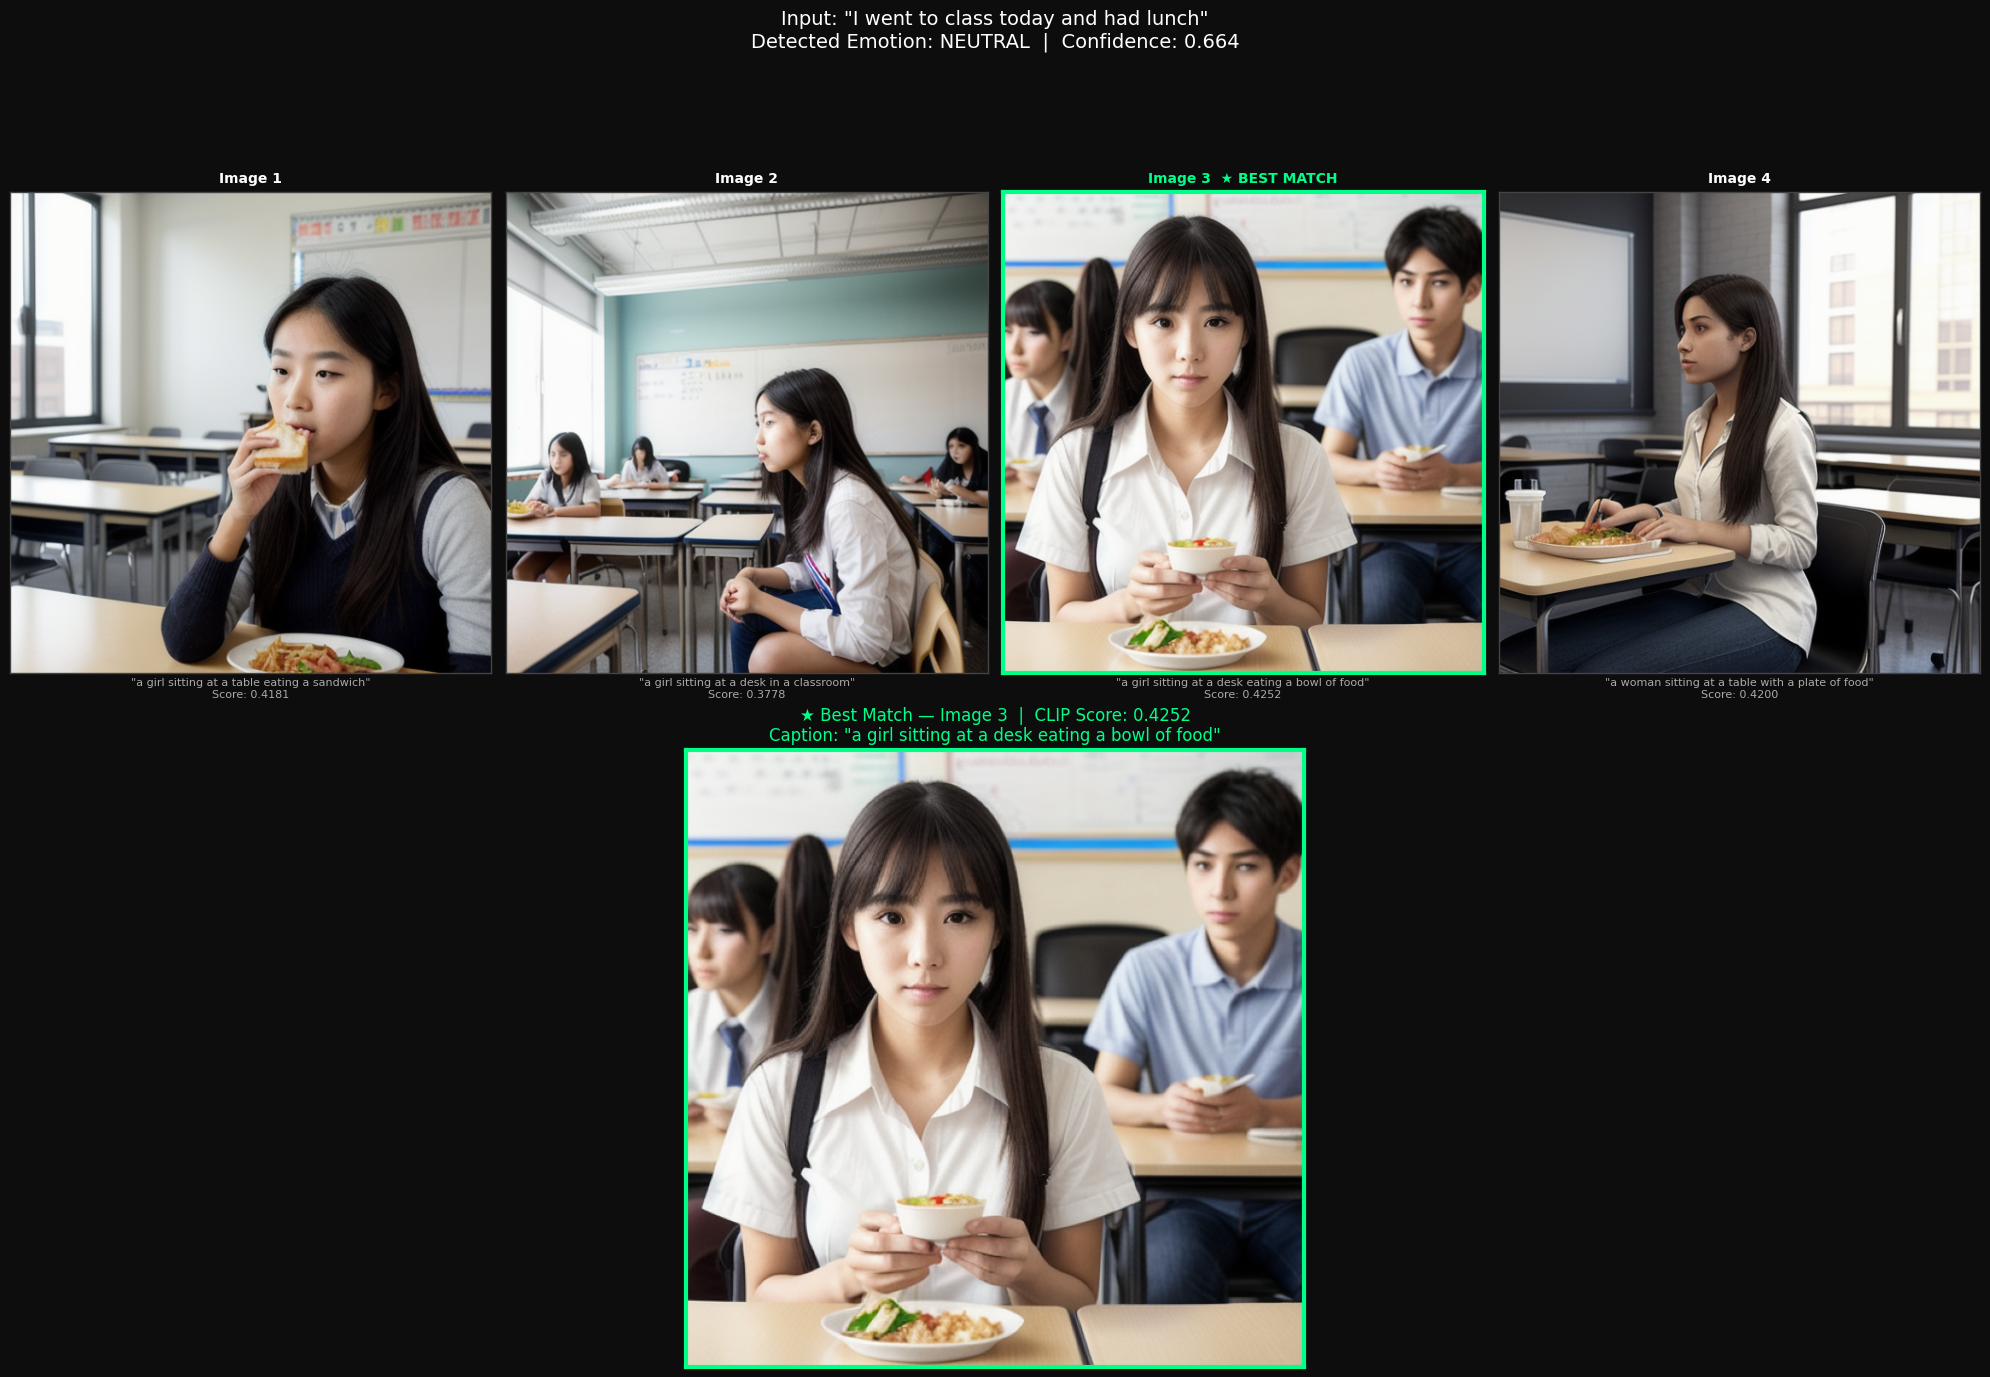

Result saved: /kaggle/working/outputs/final_result.png
JSON saved: /kaggle/working/outputs/result.json
{
  "input_text": "I went to class today and had lunch",
  "emotion": "neutral",
  "confidence": 0.6639,
  "images": [
    {
      "index": 1,
      "caption": "a girl sitting at a table eating a sandwich",
      "score": 0.41813999999999996,
      "is_best": false,
      "path": "outputs/img_1.png"
    },
    {
      "index": 2,
      "caption": "a girl sitting at a desk in a classroom",
      "score": 0.37782,
      "is_best": false,
      "path": "outputs/img_2.png"
    },
    {
      "index": 3,
      "caption": "a girl sitting at a desk eating a bowl of food",
      "score": 0.42524000000000006,
      "is_best": true,
      "path": "outputs/img_3.png"
    },
    {
      "index": 4,
      "caption": "a woman sitting at a table with a plate of food",
      "score": 0.42001999999999995,
      "is_best": false,
      "path": "outputs/img_4.png"
    }
  ],
  "best_image_index": 3,
  "

  0%|          | 0/30 [00:00<?, ?it/s]

  Generating image 2/4...


  0%|          | 0/30 [00:00<?, ?it/s]

  Generating image 3/4...


  0%|          | 0/30 [00:00<?, ?it/s]

  Generating image 4/4...


  0%|          | 0/30 [00:00<?, ?it/s]

  Saved 4 images to /kaggle/working/outputs

[Phase 4] Captioning all images...
  Captioning image 1/4...
  Captioning image 2/4...
  Captioning image 3/4...
  Captioning image 4/4...
  Image 1: a woman sitting at a desk writing in a notebook
  Image 2: a young girl sitting at a desk writing
  Image 3: a woman sitting at a desk with a pen in her hand
  Image 4: a woman sitting in front of a computer

[Phase 5+6] Ranking with CLIP...
  Image-text scores : [0.2328, 0.2228, 0.2369, 0.1939]
  Caption-text scores: [0.6289, 0.5873, 0.6101, 0.6451]
  Combined scores   : [0.3912, 0.3686, 0.3862, 0.3744]
  Best image        : #1 (score: 0.3912)

[Phase 7] Displaying results...


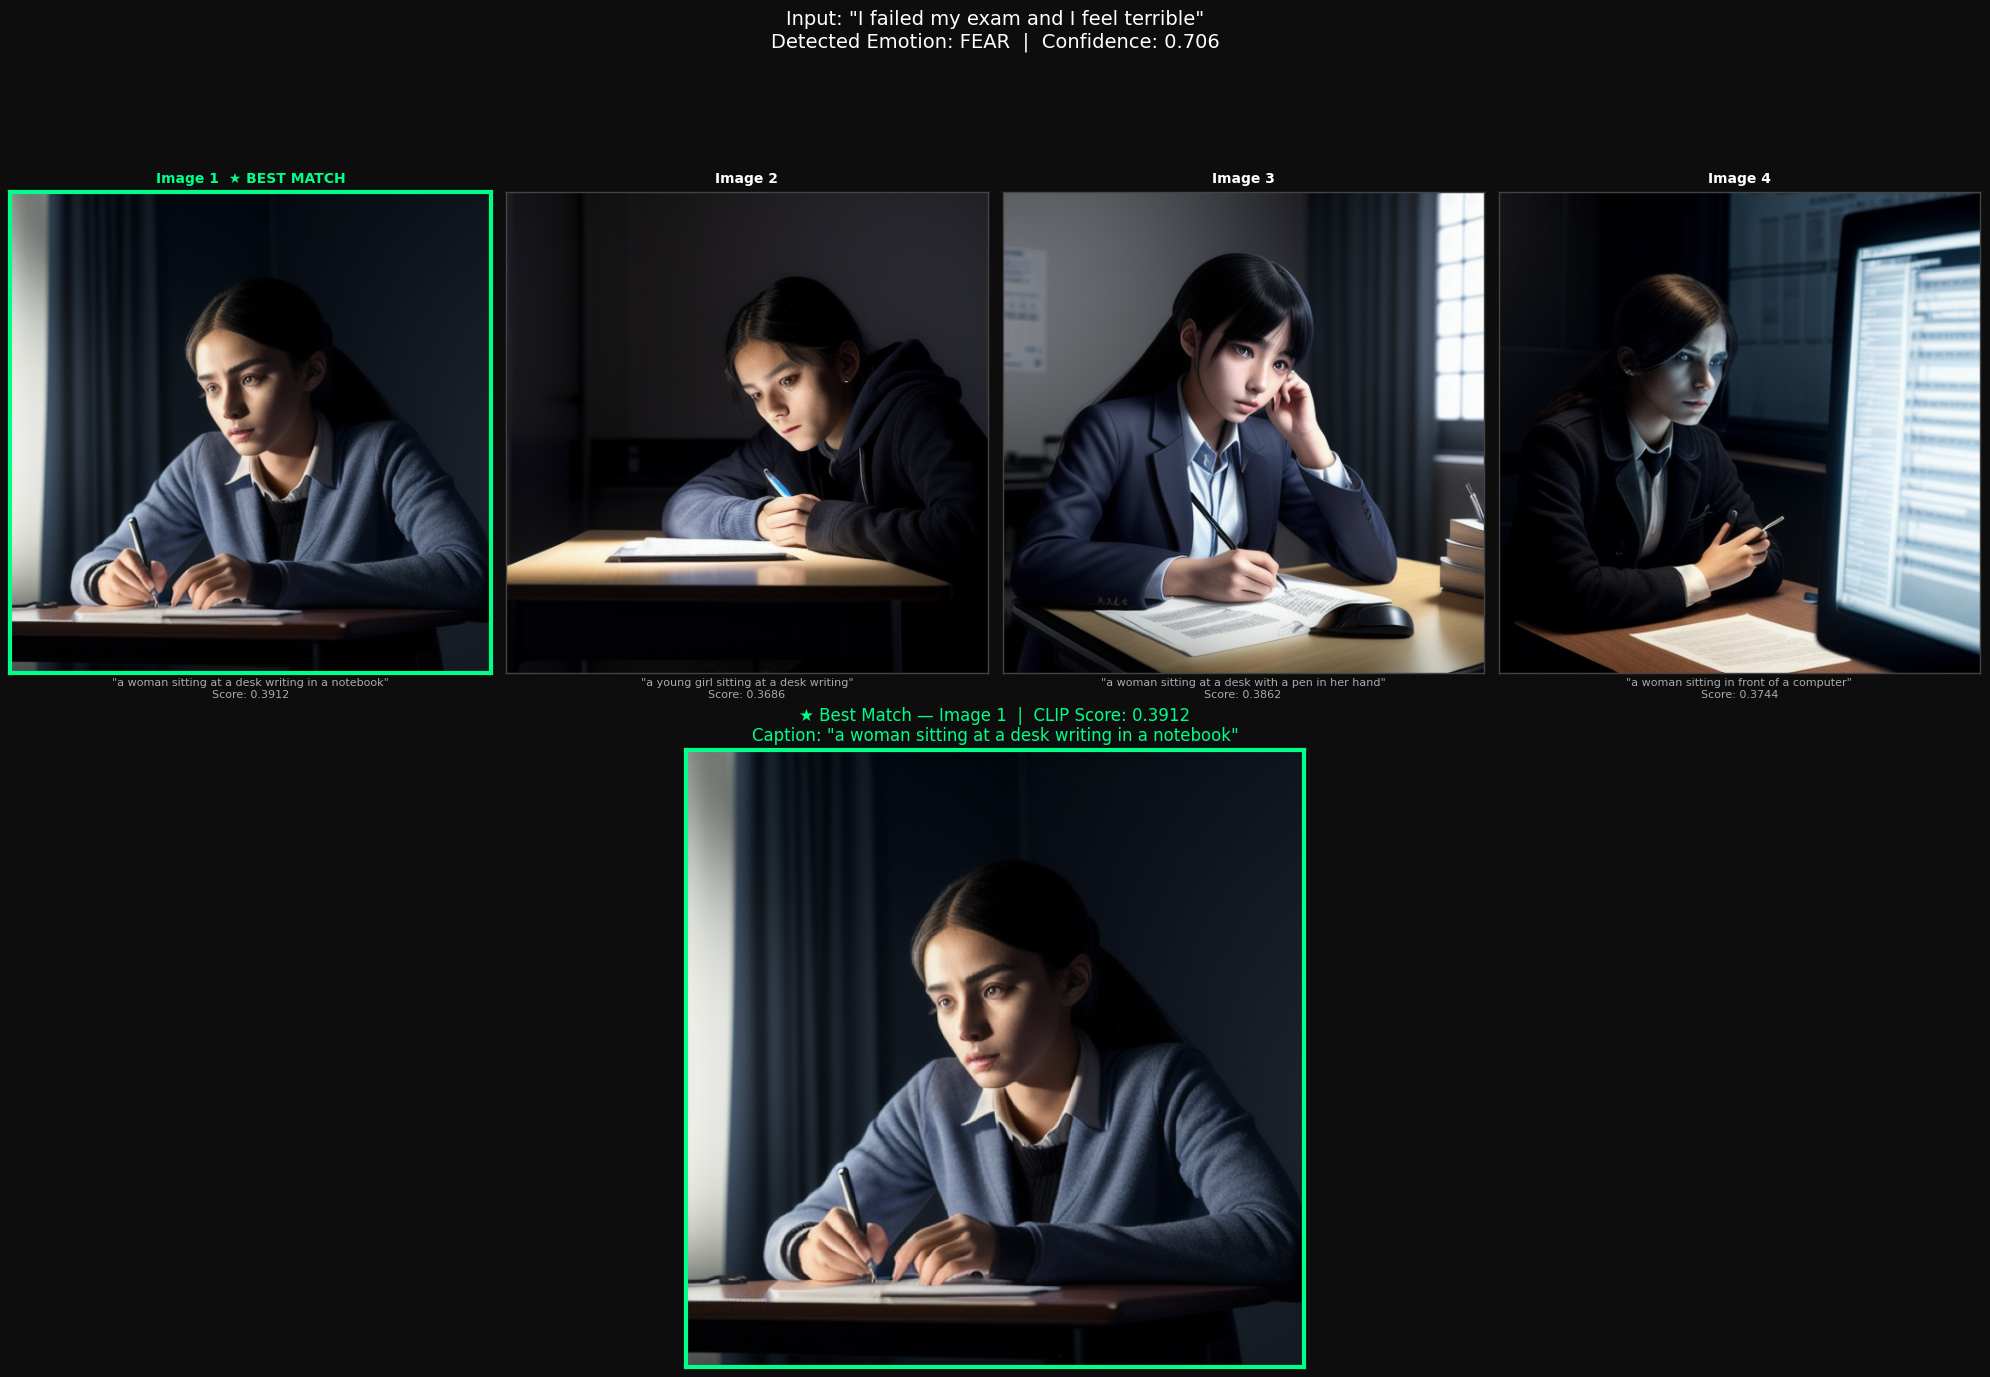

Result saved: /kaggle/working/outputs/final_result.png
JSON saved: /kaggle/working/outputs/result.json
{
  "input_text": "I failed my exam and I feel terrible",
  "emotion": "fear",
  "confidence": 0.7055,
  "images": [
    {
      "index": 1,
      "caption": "a woman sitting at a desk writing in a notebook",
      "score": 0.39124000000000003,
      "is_best": true,
      "path": "outputs/img_1.png"
    },
    {
      "index": 2,
      "caption": "a young girl sitting at a desk writing",
      "score": 0.36860000000000004,
      "is_best": false,
      "path": "outputs/img_2.png"
    },
    {
      "index": 3,
      "caption": "a woman sitting at a desk with a pen in her hand",
      "score": 0.38617999999999997,
      "is_best": false,
      "path": "outputs/img_3.png"
    },
    {
      "index": 4,
      "caption": "a woman sitting in front of a computer",
      "score": 0.37438,
      "is_best": false,
      "path": "outputs/img_4.png"
    }
  ],
  "best_image_index": 1,
  "best_s

  0%|          | 0/30 [00:00<?, ?it/s]

  Generating image 2/4...


  0%|          | 0/30 [00:00<?, ?it/s]

  Generating image 3/4...


  0%|          | 0/30 [00:00<?, ?it/s]

  Generating image 4/4...


  0%|          | 0/30 [00:00<?, ?it/s]

  Saved 4 images to /kaggle/working/outputs

[Phase 4] Captioning all images...
  Captioning image 1/4...
  Captioning image 2/4...
  Captioning image 3/4...
  Captioning image 4/4...
  Image 1: a woman in a white shirt and tie working on a laptop
  Image 2: a woman in a suit smiling at the camera
  Image 3: a woman sitting at her desk using a laptop
  Image 4: a woman sitting at a desk with her laptop

[Phase 5+6] Ranking with CLIP...
  Image-text scores : [0.1918, 0.1911, 0.1984, 0.1979]
  Caption-text scores: [0.4949, 0.6189, 0.5649, 0.5739]
  Combined scores   : [0.313, 0.3622, 0.345, 0.3483]
  Best image        : #2 (score: 0.3622)

[Phase 7] Displaying results...


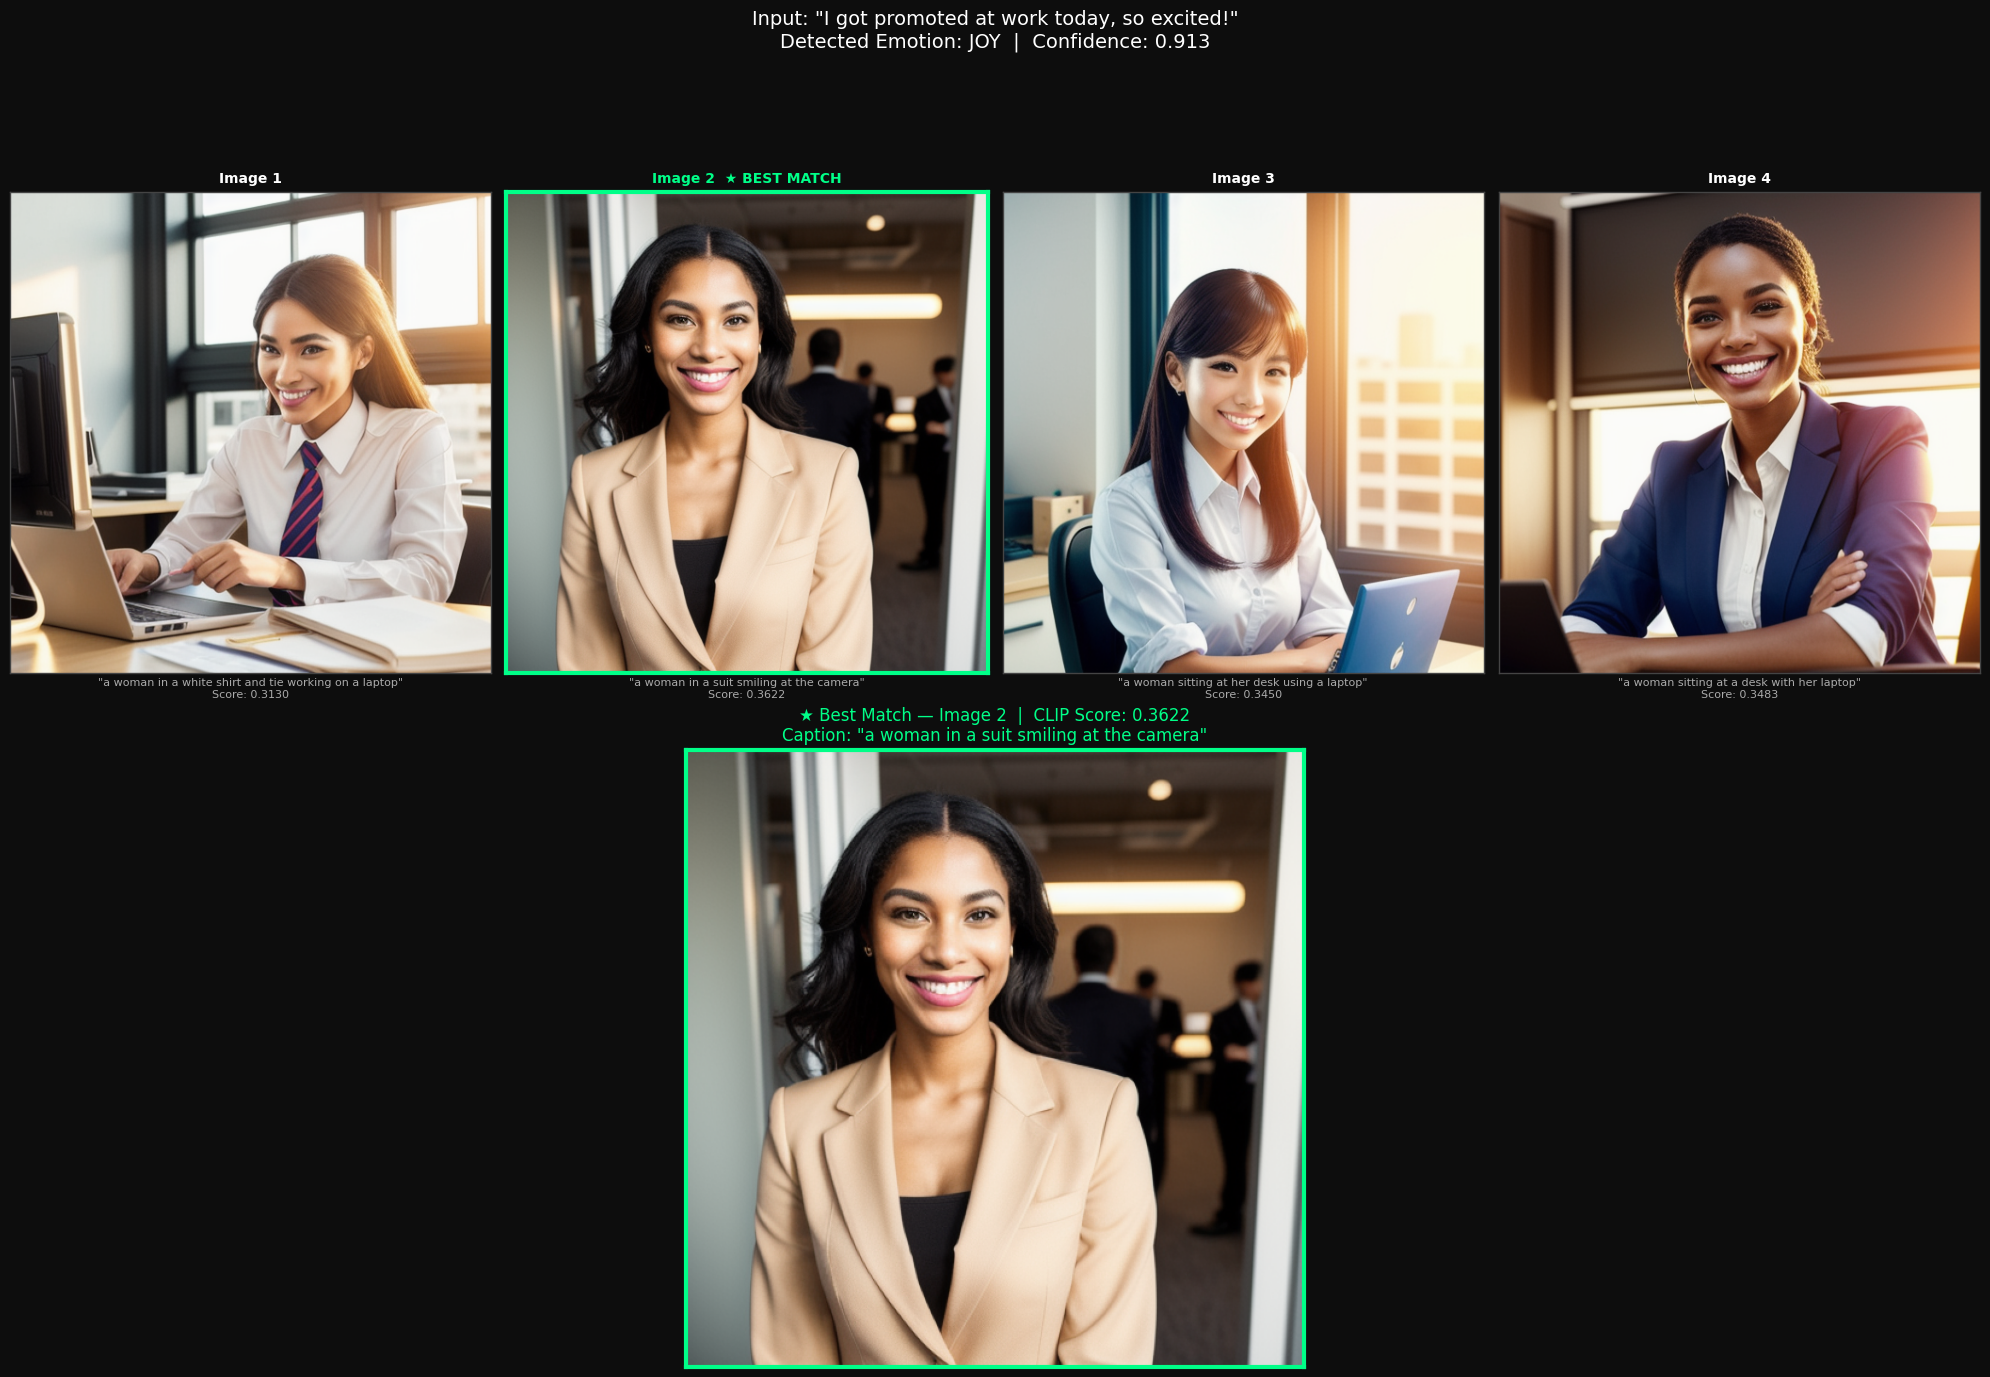

Result saved: /kaggle/working/outputs/final_result.png
JSON saved: /kaggle/working/outputs/result.json
{
  "input_text": "I got promoted at work today, so excited!",
  "emotion": "joy",
  "confidence": 0.9126,
  "images": [
    {
      "index": 1,
      "caption": "a woman in a white shirt and tie working on a laptop",
      "score": 0.31304,
      "is_best": false,
      "path": "outputs/img_1.png"
    },
    {
      "index": 2,
      "caption": "a woman in a suit smiling at the camera",
      "score": 0.36222,
      "is_best": true,
      "path": "outputs/img_2.png"
    },
    {
      "index": 3,
      "caption": "a woman sitting at her desk using a laptop",
      "score": 0.345,
      "is_best": false,
      "path": "outputs/img_3.png"
    },
    {
      "index": 4,
      "caption": "a woman sitting at a desk with her laptop",
      "score": 0.34829999999999994,
      "is_best": false,
      "path": "outputs/img_4.png"
    }
  ],
  "best_image_index": 2,
  "best_score": 0.3622
}

✓ 

  0%|          | 0/30 [00:00<?, ?it/s]

  Generating image 2/4...


  0%|          | 0/30 [00:00<?, ?it/s]

  Generating image 3/4...


  0%|          | 0/30 [00:00<?, ?it/s]

  Generating image 4/4...


  0%|          | 0/30 [00:00<?, ?it/s]

  Saved 4 images to /kaggle/working/outputs

[Phase 4] Captioning all images...
  Captioning image 1/4...
  Captioning image 2/4...
  Captioning image 3/4...
  Captioning image 4/4...
  Image 1: a woman sitting at a desk with a pen and notebook
  Image 2: a young girl holding a piece of paper in her hand
  Image 3: a boy in a school uniform holding a book
  Image 4: a woman sitting at a desk writing in a book

[Phase 5+6] Ranking with CLIP...
  Image-text scores : [0.198, 0.2215, 0.2174, 0.2103]
  Caption-text scores: [0.5348, 0.5483, 0.591, 0.6098]
  Combined scores   : [0.3327, 0.3522, 0.3668, 0.3701]
  Best image        : #4 (score: 0.3701)

[Phase 7] Displaying results...


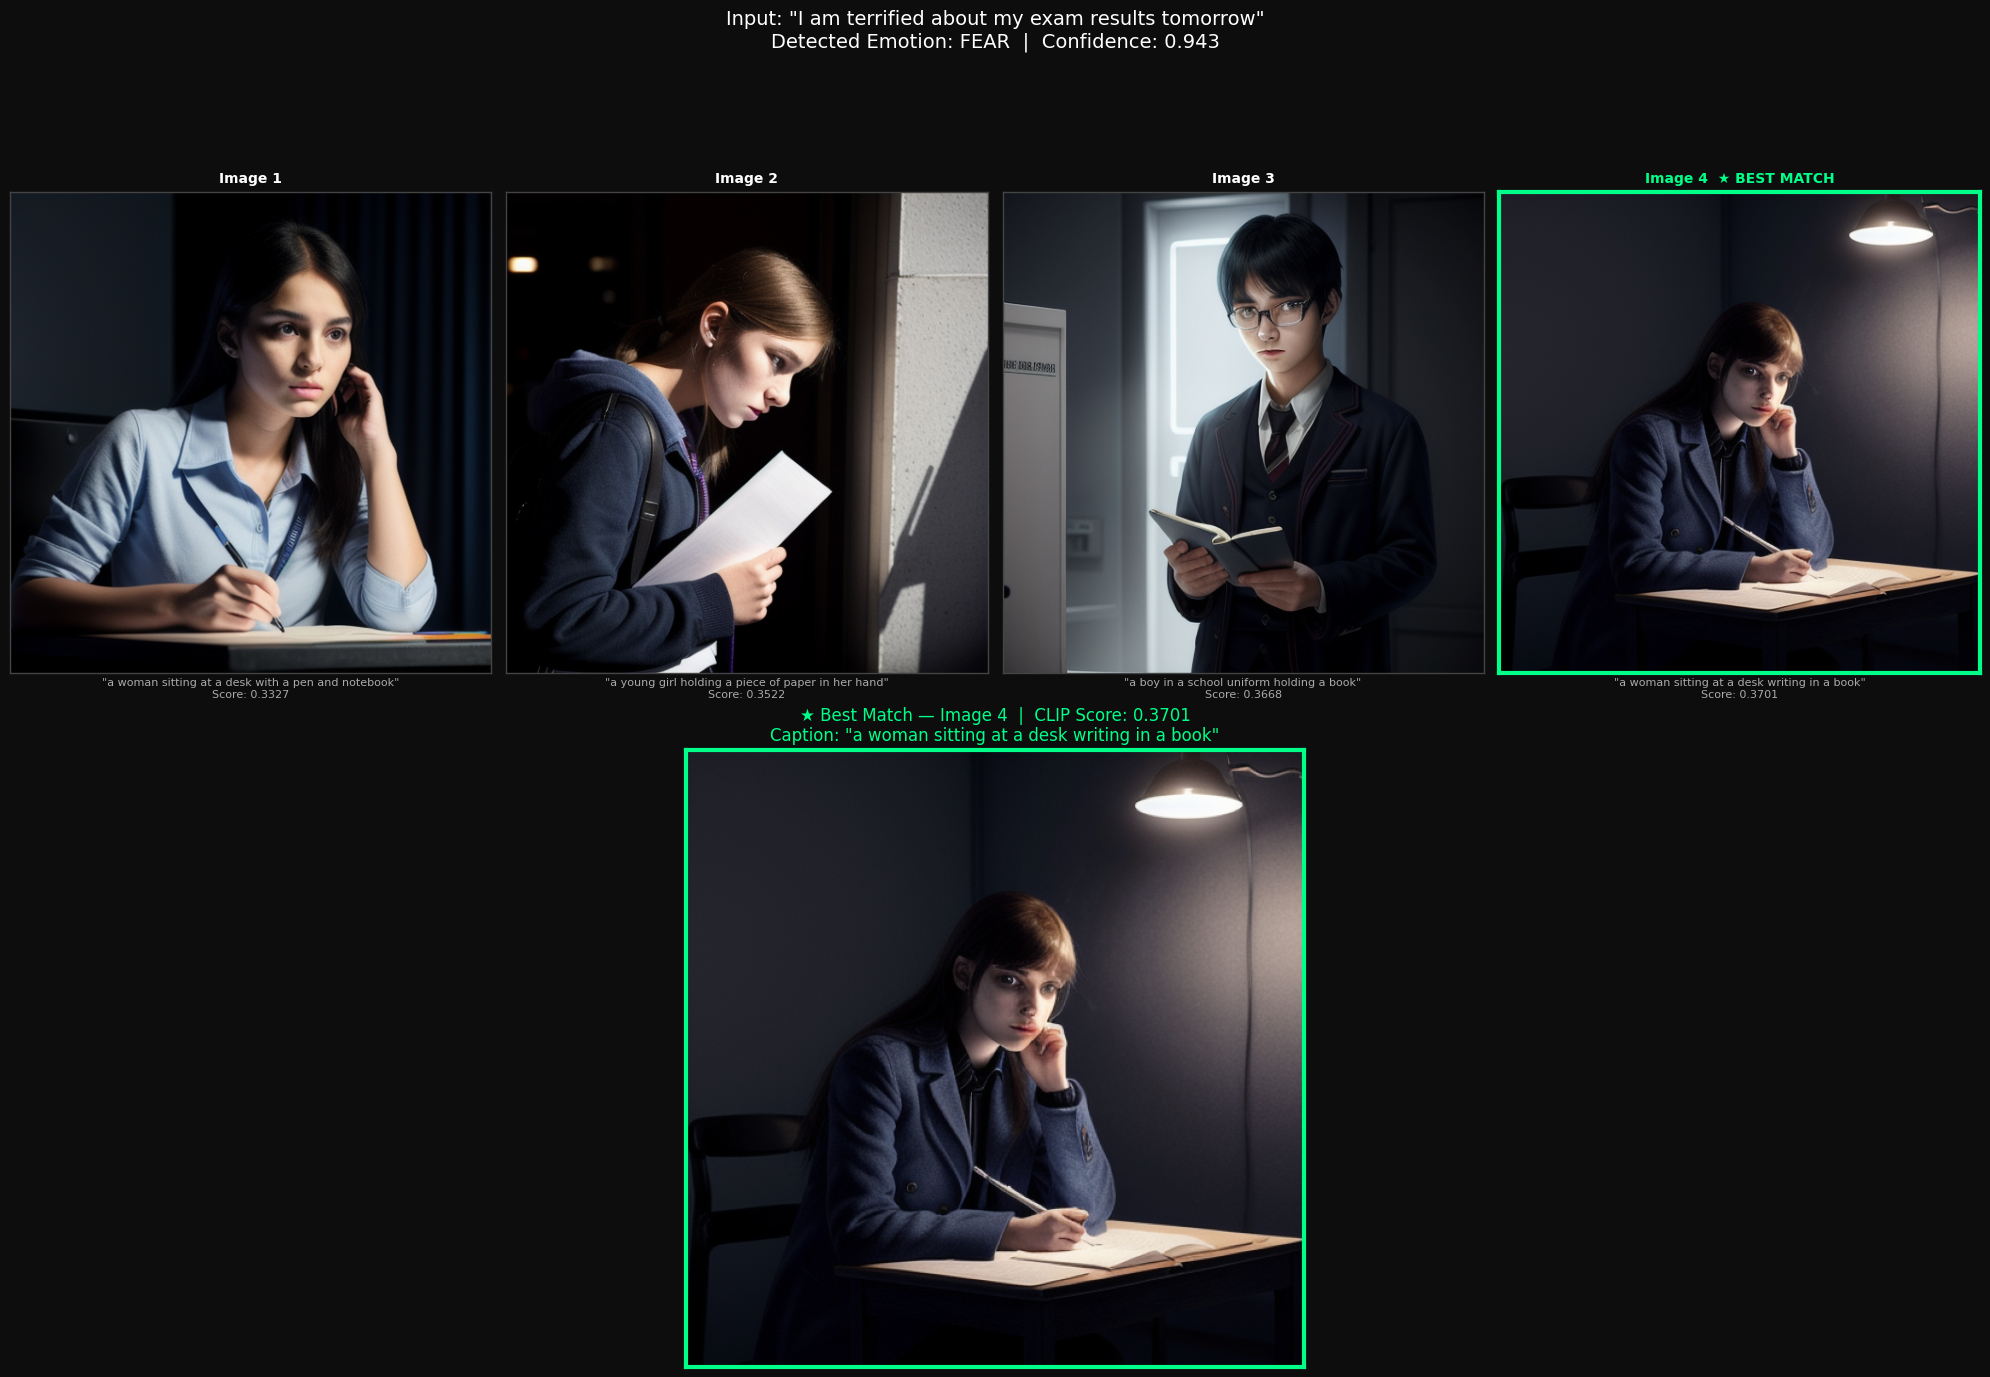

Result saved: /kaggle/working/outputs/final_result.png
JSON saved: /kaggle/working/outputs/result.json
{
  "input_text": "I am terrified about my exam results tomorrow",
  "emotion": "fear",
  "confidence": 0.943,
  "images": [
    {
      "index": 1,
      "caption": "a woman sitting at a desk with a pen and notebook",
      "score": 0.33272,
      "is_best": false,
      "path": "outputs/img_1.png"
    },
    {
      "index": 2,
      "caption": "a young girl holding a piece of paper in her hand",
      "score": 0.35222,
      "is_best": false,
      "path": "outputs/img_2.png"
    },
    {
      "index": 3,
      "caption": "a boy in a school uniform holding a book",
      "score": 0.36684,
      "is_best": false,
      "path": "outputs/img_3.png"
    },
    {
      "index": 4,
      "caption": "a woman sitting at a desk writing in a book",
      "score": 0.3701,
      "is_best": true,
      "path": "outputs/img_4.png"
    }
  ],
  "best_image_index": 4,
  "best_score": 0.3701
}

✓ 

In [13]:
test_inputs = [
    "I went to class today and had lunch",
    "I failed my exam and I feel terrible",
    "I got promoted at work today, so excited!",
    "I am terrified about my exam results tomorrow",
]

for i, text in enumerate(test_inputs):
    run_full_pipeline(text, seed=42 + i * 10)
    print("\n" + "─"*65 + "\n")